In [ ]:
!pip install --upgrade backoff -q
!pip install --upgrade openai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 17.2 MB/s eta 0:00:00


In [ ]:


questions = [
    "Read the following speech excerpt and evaluate how confident the speaker sounds. Answer with a number between 0 and 1, where 0 means 'not confident at all' and 1 means 'extremely confident.' Provide only the numerical rating.",

    "Analyze the following speech excerpt and rate the level of optimism in the speaker’s language. Answer with a number between 0 and 1, where 0 represents a very pessimistic tone, 0.5 represents a neutral or realistic tone, and 1 represents highly optimistic language. Provide only the numerical rating.",

    "Based on the following speech excerpt, evaluate how certain or definitive the speaker is about the company's performance. Respond with a number between 0 and 1, where 0 indicates a high level of uncertainty and 1 indicates complete certainty. Provide only the numerical rating.",

    "Analyze the following speech excerpt. How much does the speaker focus on future plans compared to current performance? Answer with a number between 0 and 1, where 0 means the speech is entirely focused on present details, and 1 means the speech is entirely focused on future plans. Provide only the numerical rating.",

    "Examine the following speech excerpt and rate the speaker's inclination towards risk-taking. Use a scale from 0 to 1, where 0 indicates complete caution and 1 indicates a high propensity for risk-taking. Provide only the numerical rating.",

    "Review the following speech excerpt. To what extent does the speaker emphasize strategic, long-term vision over tactical, short-term details? Answer with a number between 0 and 1, where 0 indicates a focus entirely on tactical details and 1 indicates a focus entirely on strategic vision. Provide only the numerical rating.",

    "Analyze the following speech excerpt. Rate the level of emotional engagement or passion in the speaker's language using a scale from 0 to 1, where 0 means the speech is very reserved and 1 means it is highly passionate and energetic. Provide only the numerical rating.",

    "Evaluate the speaker’s emphasis on innovation in the speech excerpt. Use a scale from 0 to 1, where 0 means no mention of innovation, 0.5 means moderate emphasis on past or present innovation, and 1 means a strong focus on future-driven transformative ideas.",

    "Read the following speech excerpt and evaluate how transparent the speaker is about the company's challenges. Answer with a number between 0 and 1, where 0 means 'not transparent at all' (avoiding or downplaying issues) and 1 means 'extremely transparent' (openly addressing difficulties). Provide only the numerical rating.",

    "Examine the following speech excerpt and rate the level of accountability the speaker demonstrates regarding past mistakes or setbacks. Use a scale from 0 to 1, where 0 indicates no acknowledgment of responsibility and 1 indicates full accountability. Provide only the numerical rating.",

    "Analyze the following speech excerpt. Evaluate how resilient or adaptive the speaker sounds when discussing challenges and changes in the market. Answer with a number between 0 and 1, where 0 means the speech reflects little to no resilience and 1 means it reflects a high level of adaptability. Provide only the numerical rating.",

    "Review the following speech excerpt and assess how balanced the speaker is in discussing both risks and opportunities. Use a scale from 0 to 1, where 0 indicates an extremely risk-averse perspective and 1 indicates a perspective that equally weighs risks with potential opportunities. Provide only the numerical rating.",

    "Examine the following speech excerpt. To what extent does the speaker rely on concrete evidence (examples, facts, or detailed reasoning) to support their statements about company performance? Answer with a number between 0 and 1, where 0 means the speech is entirely abstract and 1 means it is heavily supported by concrete evidence.",

    "Read the following speech excerpt and evaluate how much the speaker emphasizes collaboration and teamwork as keys to the company's success. Use a scale from 0 to 1, where 0 indicates no mention of collaborative efforts and 1 indicates a strong emphasis on teamwork and collective achievement. Provide only the numerical rating.",

    "Analyze the following speech excerpt. Rate the extent to which the speaker focuses on sustainable, long-term impact versus short-term gains. Answer with a number between 0 and 1, where 0 represents a focus entirely on immediate results and 1 represents a focus entirely on long-term sustainability. Provide only the numerical rating.",

    "Read the following speech excerpt. How much does the speaker use hedging language (e.g., 'perhaps,' 'likely,' 'we are exploring options') instead of making definitive statements? Answer with a number between 0 and 1, where 0 means no hedging, 0.5 means moderate hedging, and 1 means heavy hedging.",

    "Read the following speech excerpt. How much does the speaker emphasize collaboration and inclusivity when discussing company performance? Use a scale from 0 to 1, where 0 means the speech is entirely self-focused ('I' statements), 0.5 means balanced between 'I' and 'we,' and 1 means strong emphasis on teamwork and collective success."
]


In [ ]:
from openai import OpenAI
import openai
import time
import backoff
client = OpenAI(api_key='YOUR_API_KEY_HERE') # Replace with a placeholder or use Colab secrets
from tqdm.auto import tqdm
import numpy as np

@backoff.on_exception(backoff.expo, openai.RateLimitError, max_time=60, max_tries=6)
def get_response(text, question, repeat):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
                {"role": "developer", "content": f'{question} Reply nothing but the number please.'},
                {"role": "user", "content": text}  # Truncate to avoid length issues
            ],
        temperature=0.6,
        max_completion_tokens=5,
        n=repeat
    )

    ratings = []
    for choice in response.choices:
        rating = choice.message.content.strip()
        try:
            rating = float(rating)
            if 0 <= rating <= 1:
                ratings.append(rating)
        except Exception as e:
            # continue
            print(e)

    return ratings  # Return list of valid numerical responses

def gpt_analyze(text, repeat, questions=questions):
    """
    Runs the analysis by querying GPT-4o-mini multiple times per question.

    Parameters:
    - text (str): The CEO speech to analyze.
    - questions (list): List of analysis questions.
    - repeat (int): Number of times to repeat each question.

    Returns:
    - dict: Dictionary where keys are question indices and values are lists of responses.
    """
    answers = []

    for question in questions:
        responses = get_response(text, question, repeat=repeat)
        answers.append([r for r in responses if r is not None])  # Remove invalid responses

    return answers

from tqdm.auto import tqdm
import pandas as pd
import time
def extract_feature_gpt(df):
    """
    Extracts features from the 'text' column of a DataFrame using GPT analysis.

    Args:
        df: A pandas DataFrame containing 'date' and 'text' columns.

    Returns:
        A pandas DataFrame with extracted features and sorted by date.
    """
    feature_list = []
    # print()
    for _, row in tqdm(df.iterrows(), total=df.shape[0]):

        # t0 = time.time()
        temp_answers = gpt_analyze(row['text'], repeat=10)
        # print(time.time()-t0)

        for _ in range(5):
            features = {}
            for i in range(len(questions)):
                features[i] = np.random.choice(temp_answers[i])
            random_days = int(np.random.normal(loc=0, scale=8))
            features['date'] = pd.to_datetime(row['date'])
            # features['date'] = pd.to_datetime(row['date']) + pd.Timedelta(days=random_days)
            features['text'] = row['text']
            feature_list.append(features)
    df_features = pd.DataFrame(feature_list)
    df_features = df_features.sort_values(by='date').reset_index(drop=True)
    return df_features

In [ ]:


from datetime import date

today = date.today()
print(today)


import pandas as pd

def convert_to_number(value):
    if isinstance(value, str):  # Check if the value is a string
        value = value.strip()  # Remove leading/trailing spaces
        if 'M' in value:  # Convert millions to billions
            return float(value.replace('M', '').strip()) / 1000
        elif 'B' in value:  # Keep billions as is (remove 'B')
            return float(value.replace('B', '').strip())
    return value  # Return as is if no conversion needed

def prepare_surp_targets(file_path, shift=False):
    """
    Reads an Excel file, processes the data to handle dates and numeric conversions,
    and interpolates missing values.

    Args:
        file_path: The path to the Excel file.
        col: The column containing percentage values to be processed.

    Returns:
        A pandas DataFrame with processed data indexed by date.
    """
    col = '%Surp'
    df_eps = pd.read_excel(file_path, engine='openpyxl')[['Ann Date', col, 'Estimate']].dropna(subset=['Estimate'])
    # print(df_eps)
    # df_eps = pd.read_excel(file_path, engine='openpyxl')[['Ann Date', col]].dropna()
    df_eps['Ann Date'] = pd.to_datetime(df_eps['Ann Date'])

    future_df = df_eps[df_eps['Ann Date'] > pd.to_datetime(today)]

    # Find the earliest date after the given date
    if not future_df.empty:
        next_row = future_df.sort_values('Ann Date').iloc[0]
        print("Next Date:", next_row['Ann Date'].date())
        print("Estimate:", next_row['Estimate'])
    else:
        print("No future dates available.")

    df_eps[col] = pd.to_numeric(
        df_eps[col].astype(str)
        .str.replace('~', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace('B', '', regex=False)
        .str.strip(),  # Remove any leading/trailing spaces
        errors='coerce'
    )
    # print(df_eps)
    df_eps = df_eps.dropna(subset=[col]).drop(['Estimate'], axis=1)
    df_eps = df_eps.set_index('Ann Date').sort_index()

    # Ensure the index is a datetime index
    df_eps.index = pd.to_datetime(df_eps.index)

    # Create a full date range
    full_date_range = pd.date_range(start=df_eps.index.min(), end=df_eps.index.max(), freq='D')

    # Reindex without interpolation, using forward fill (previous value)
    df_eps = df_eps.reindex(full_date_range).ffill()
    # print(df_eps)
    df_eps = df_eps.reindex(full_date_range).interpolate(method='time')


    return next_row['Estimate'], df_eps

def prepare_guidance_targets(file_path, shift=False):
    """
    Reads an Excel file, processes the data to handle dates and numeric conversions,
    and interpolates missing values.

    Args:
        file_path: The path to the Excel file.
        col: The column containing percentage values to be processed.

    Returns:
        A pandas DataFrame with processed data indexed by date.
    """
    col = '%Guid Surp'
    df_eps = pd.read_excel(file_path, engine='openpyxl')[['Ann Date', col, 'Comp', 'Estimate']].dropna()
    df_eps = pd.read_excel(file_path, engine='openpyxl')[['Ann Date', col]].dropna()
    df_eps['Ann Date'] = pd.to_datetime(df_eps['Ann Date'])

    df_eps[col] = pd.to_numeric(
        df_eps[col].astype(str)
        .str.replace('~', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace('B', '', regex=False)
        .str.strip(),  # Remove any leading/trailing spaces
        errors='coerce'
    )
    df_eps = df_eps.dropna(subset=[col])
    df_eps = df_eps.set_index('Ann Date').sort_index()

    # Ensure the index is a datetime index
    df_eps.index = pd.to_datetime(df_eps.index)

    # Create a full date range
    full_date_range = pd.date_range(start=df_eps.index.min(), end=df_eps.index.max(), freq='D')

    # Reindex without interpolation, using forward fill (previous value)
    df_eps = df_eps.reindex(full_date_range).ffill()
    # print(df_eps)
    df_eps = df_eps.reindex(full_date_range).interpolate(method='time')


    return df_eps






2025-09-05


In [ ]:
# prompt: read the folder folloing foloder path. The folder contains csv files, so you should read them as dfs and then combine into one. the files have the same columns

import pandas as pd
import os

def combine_csv_files(folder_path):
    """
    Reads all CSV files in a folder, combines them into a single DataFrame,
    converts the 'date' column to datetime format, sorts by date, and returns the combined DataFrame.

    Args:
        folder_path: The path to the folder containing the CSV files.

    Returns:
        A pandas DataFrame containing the combined data from all CSV files, or None
        if no CSV files are found or an error occurs.
    """
    all_dfs = []
    for filename in tqdm(os.listdir(folder_path)):
        if filename.endswith(".csv"):
            filepath = os.path.join(folder_path, filename)
            try:
                # df = pd.read_csv(filepath)
                # all_dfs.append(df)
                df = pd.read_csv(filepath)

                # Standardize column names (case-insensitive match)
                df.columns = df.columns.str.strip().str.lower()

                try:
                    df = df[['date', 'text']]
                    # df['text'] = df['text'].apply(lambda x: x.replace('\\', ''))
                    # df['date'] = pd.to_datetime(df['date'], format='mixed', errors='raise'
                    all_dfs.append(df)
                except:
                    print(f"Warning: Skipping {filename} due to missing 'Date' or 'Text' column.")

            except pd.errors.EmptyDataError:
                print(f"Warning: Skipping empty file {filename}")
            except pd.errors.ParserError:
                print(f"Warning: Skipping file with parsing error: {filename}")
            except Exception as e:
                print(f"Error reading {filename}: {e}")

    if not all_dfs:
        print("No CSV files found in the specified folder.")
        return None

    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df['date'] = pd.to_datetime(combined_df['date'], format='mixed', errors='raise')
    combined_df = combined_df.sort_values(by='date', ascending=True).reset_index(drop=True)

    grouped_df = combined_df.groupby('date')['text'].apply(lambda x: '\n'.join(x)).reset_index()

    # print(f"Successfully processed {len(csv_files)} CSV files.")
    print(f"Final dataset contains {len(grouped_df)} unique dates.")

    return grouped_df

    return combined_df


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error


def train_nn_regressor(X_train, y_train):
    """
    Train a multi-output regression model with 17 input features and 2 output labels.
    """
    if True:
        # Normalize input data
        normalizer = layers.Normalization()
        normalizer.adapt(X_train)

        # Add noise to input features for robustness
        X_train = X_train + np.random.normal(0, 0.03, X_train.shape)

        # Define the model
        inputs = keras.Input(shape=(X_train.shape[1],))
        x = normalizer(inputs)

        # Hidden layers with skip connections
        x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
        x = layers.Dropout(0.3)(x)

        skip = layers.Dense(64, activation='relu')(x)
        x = layers.Dense(64, activation='relu')(skip)
        x = layers.Add()([x, skip])  # Residual connection

        x = layers.Dense(32, activation='relu')(x)
        outputs = layers.Dense(2, activation='linear')(x)  # Two output neurons

        model = keras.Model(inputs, outputs)

        # Optimizer with learning rate schedule
        lr_schedule = keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=0.0003, decay_steps=1000, decay_rate=0.9
        )
        optimizer = Adam(learning_rate=lr_schedule)
        model.compile(optimizer=optimizer, loss=Huber(delta=1.0), metrics=['mae'])

        # Early stopping
        early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

        # Train the model
        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=64,
            verbose=0,
            validation_split=0.3,
            callbacks=[early_stopping]
        )

        # Plot training vs. validation loss
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training vs Validation Loss')
        plt.show()
    else:
        model = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42))
        model.fit(X_train, y_train)
        # Make predictions
        y_pred = model.predict(X_train)

        # Compute MSE
        mse = mean_squared_error(y_train, y_pred)
        print(f'Test MSE: {mse}')


    return model


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold

def train_nn_regressor_cv(X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_predictions = np.zeros_like(y, dtype=float)
    all_true = np.array(y)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Add noise to training features
        # X_train = X_train + np.random.normal(0, 0.03, X_train.shape)

        model = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42))
        model.fit(X_train, y_train)
        # Make predictions
        y_pred = model.predict(X_train)

        # Compute MSE
        mse = mean_squared_error(y_train, y_pred)
        print(f'Test MSE: {mse}')

        all_predictions[test_idx] = y_pred

    # Plot true vs predicted values
    for i in range(1):
        plt.figure(figsize=(8, 6))
        plt.scatter(all_true[:, i], all_predictions[:, i], alpha=0.6, edgecolors='k')
        plt.plot([min(all_true[:, i]), max(all_true[:, i])], [min(all_true[:, i]), max(all_true[:, i])], linestyle='--', color='red')
        plt.xlabel('True Values')
        plt.ylabel('Predicted Values')
        plt.title(f'True vs Predicted Values (Target {i+1})')
        plt.show()

    return all_true, all_predictions


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
def plot_predictions(predictions, ax, ylabel="Value"):
    """Generate a violin plot of predictions with a unique y-axis and label."""
    data = np.array(predictions).squeeze()
    mean_val = np.mean(data)
    median_val = np.median(data)

    sns.violinplot(
        data=data,
        color="skyblue",
        linewidth=2,
        ax=ax
    )

    ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_val:.2f}")
    ax.axhline(median_val, color='green', linestyle='-.', linewidth=1.5, label=f"Median: {median_val:.2f}")

    ax.set_ylabel(ylabel, fontsize=14)  # Set unique y-label
    ax.set_xticks([])  # Remove x-ticks
    ax.grid(axis='y', linestyle="--", alpha=0.5)
    ax.legend(fontsize=12, loc='upper right')


In [ ]:

import numpy as np
def run(df_text, df_target, df_target_2):
    merged_df = pd.merge(df_text[df_text['date'] > df_target.index.min()], df_target, left_on='date', right_index=True, how='left').drop_duplicates(ignore_index=True)
    merged_df = pd.merge(merged_df[merged_df['date'] > df_target_2.index.min()], df_target_2, left_on='date', right_index=True, how='left').drop_duplicates(ignore_index=True)
    # print(merged_df)
    # return
    missing_rows = merged_df[merged_df['%Surp_x'].isna()]

    # missing_rows = merged_df[merged_df['Reported'].isna()]
    available_rows = merged_df.dropna()

    print(len(missing_rows), len(available_rows))

    X = available_rows.drop(columns=['%Surp_x', '%Surp_y', 'date', 'text'])
    y = available_rows[['%Surp_x', '%Surp_y']]
    X_test = missing_rows.drop(columns=['%Surp_x', '%Surp_y', 'date', 'text'])
    print(X.shape, X_test.shape)
    model = train_nn_regressor(np.array(X), np.array(y))

    predictions = model.predict(np.array(X_test))

    return predictions




  0%|          | 0/75 [00:00<?, ?it/s]

Final dataset contains 75 unique dates.


  0%|          | 0/75 [00:00<?, ?it/s]

Next Date: 2025-12-04
Estimate: 4.644
4.644
Next Date: 2025-12-04
Estimate: 1.948B
1.948B
15 353
(353, 17) (15, 17)


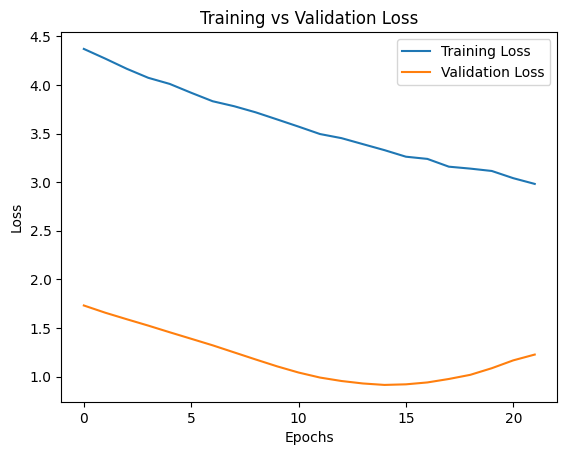

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
SNPS


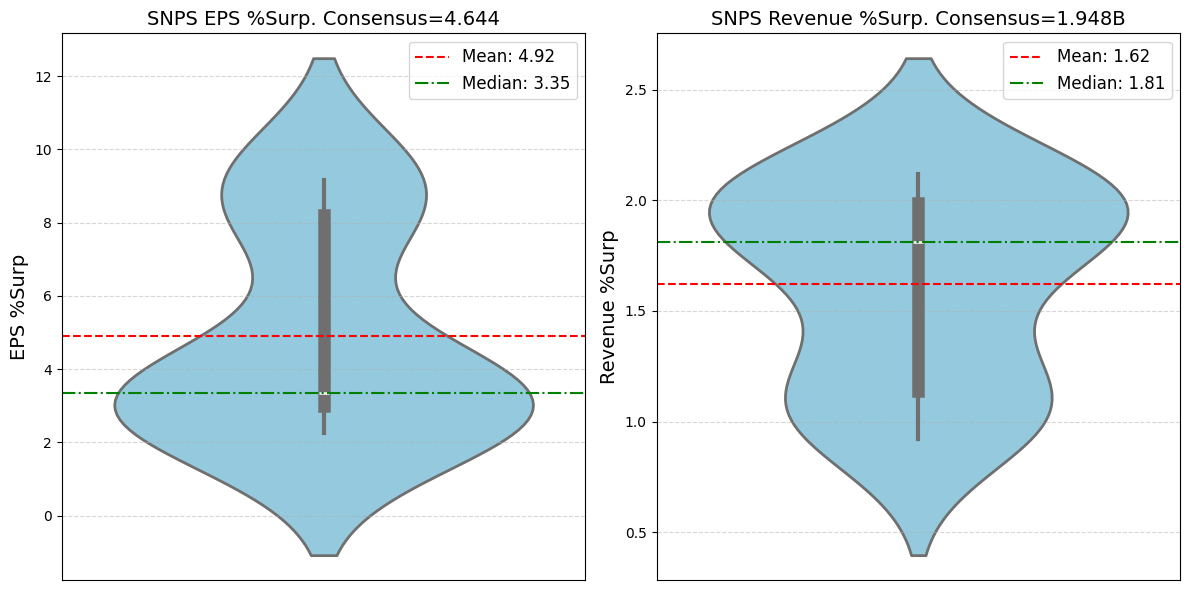

  0%|          | 0/73 [00:00<?, ?it/s]

Final dataset contains 68 unique dates.


  0%|          | 0/68 [00:00<?, ?it/s]

Next Date: 2025-09-11
Estimate: 5.179
5.179
Next Date: 2025-09-11
Estimate: 5.909B
5.909B
5 324
(324, 17) (5, 17)


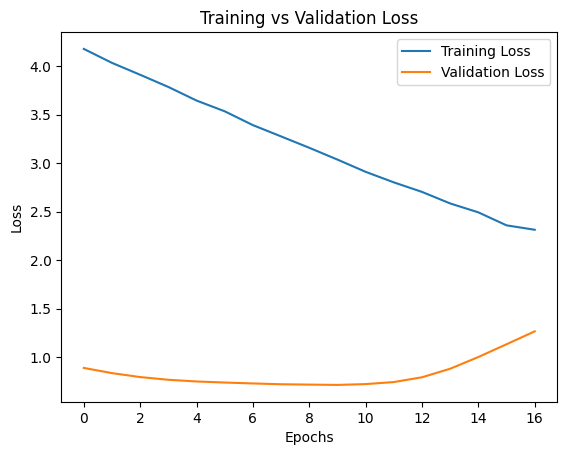

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
ADBE


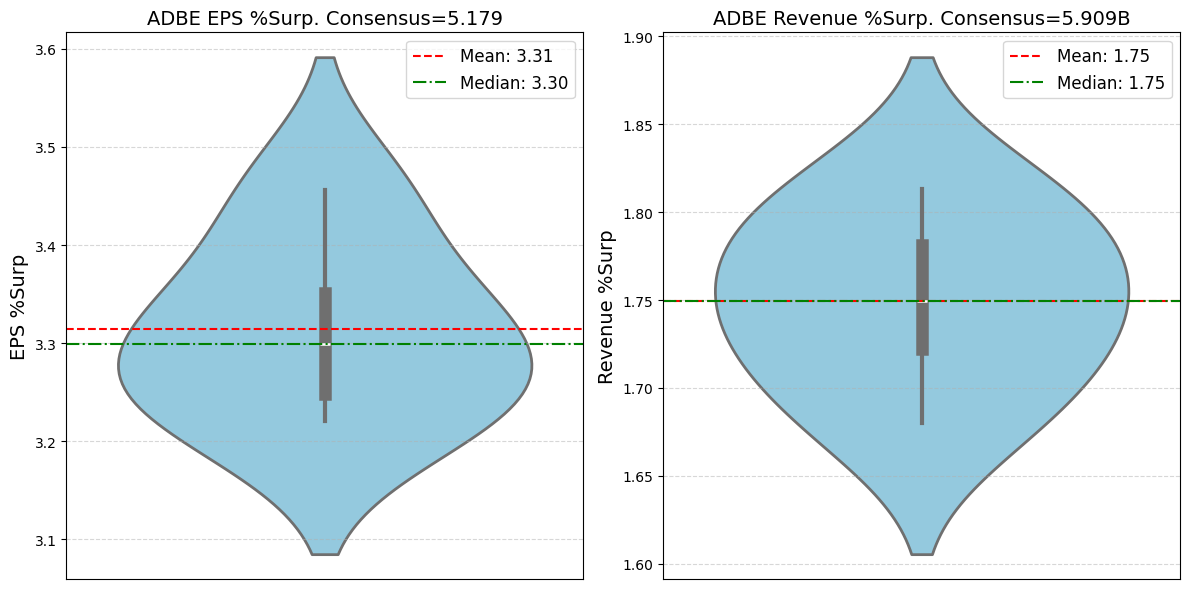

In [ ]:
for company in ['SNPS', 'ADBE']: # 'AMZN',
    folder_path = f'/path/to/your/csv/folder'  # Replace with a generic path or instructions
    combined_data = combine_csv_files(folder_path)
    combined_data = combined_data.groupby('date')['text'].apply(lambda x: '\n'.join(x)).reset_index()


    df_text = extract_feature_gpt(combined_data)

    target1, df_target = prepare_surp_targets(f'/path/to/your/{company}_eps.xlsx') # Generalize path
    print(target1)


    target2, df_target_2 = prepare_surp_targets(f'/path/to/your/{company}_revenue.xlsx') # Generalize path
    print(target2)

    predictions2 = run(df_text, df_target, df_target_2)

    print(company)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Default: no shared y-axis

    # Call the function on each axis with a unique y-label
    plot_predictions(predictions2[:,0], ax=axes[0], ylabel="EPS %Surp")
    plot_predictions(predictions2[:,1], ax=axes[1], ylabel="Revenue %Surp")

    # Add titles
    axes[0].set_title(f"{company} EPS %Surp. Consensus={target1}", fontsize=14)
    axes[1].set_title(f"{company} Revenue %Surp. Consensus={target2}", fontsize=14)

    plt.tight_layout()
    plt.show()
    # except Exception as e:
    #     print()
    #     print()
    #     print(f"Error processing {company}: {e}")
    #     print()
    #     print()
    #     continue
    # plot_filename = os.path.join("plots", f"{company}_predictions.png")
    # plt.savefig(plot_filename)

    # plt.close(fig)  # Close the figure to free up memory